<a href="https://colab.research.google.com/github/VladyslavBiblyi/CSC-349-OL1/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

##Task 1: Load the dataset into a Pandas DataFrame.

In [44]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)
tc_churn = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


##Task 2: Use structural inspection methods to analyze features

In [52]:
tc_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
tc_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [49]:
tc_churn[['Contract','PaymentMethod']].describe()
tc_churn['TotalCharges'] = pd.to_numeric(tc_churn['TotalCharges'], errors='coerce')
tc_churn[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


##Task 3: Drop any non-informative identifiers (such as customerID).

In [53]:
tc_churn = tc_churn.drop(columns=['customerID'])

##Task 4: Quantify any missing or implicit missing values across the columns and implement a structured imputation strategy

In [56]:
X = tc_churn.drop(columns=['Churn'])
y = tc_churn['Churn']

print(tc_churn.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


##Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling to numerical columns and encoding to categorical columns.

In [58]:
num_features = X.select_dtypes(include='number').columns
cat_features = X.select_dtypes(include='object').columns

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

##Task 6: Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [62]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42))
])

print("Pipeline constructed successfully.")

Pipeline constructed successfully.


##Task 7: 3 different train/test split ratios, fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC

80/20

Classification Report - 80/20:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1036
         Yes       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409



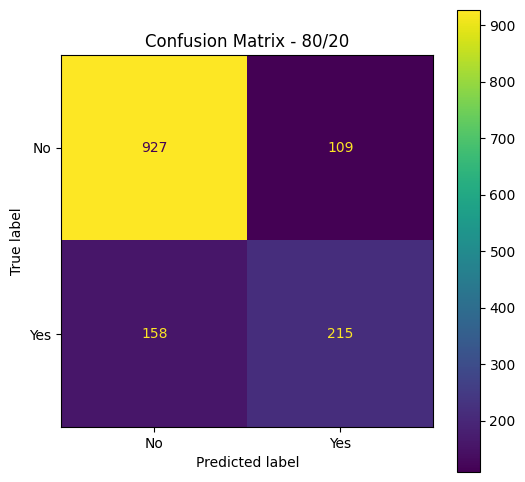

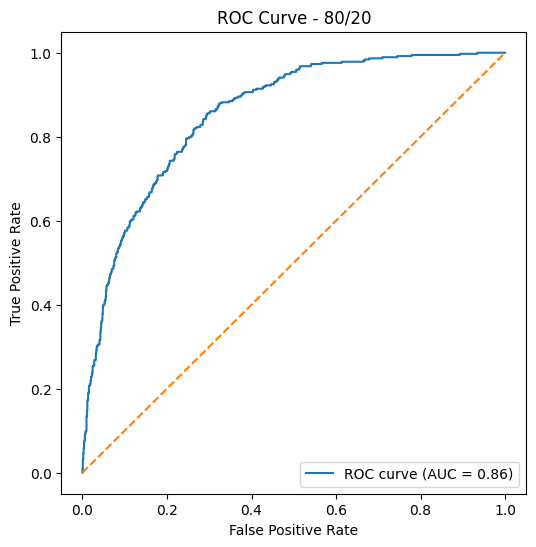

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_scores = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report - 80/20:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, ax=ax)
plt.title('Confusion Matrix - 80/20')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 80/20')
plt.legend(loc="lower right")
plt.show()

70/30

Classification Report - 70/30:
              precision    recall  f1-score   support

          No       0.79      0.96      0.87      1539
         Yes       0.74      0.32      0.45       574

    accuracy                           0.78      2113
   macro avg       0.76      0.64      0.66      2113
weighted avg       0.78      0.78      0.75      2113



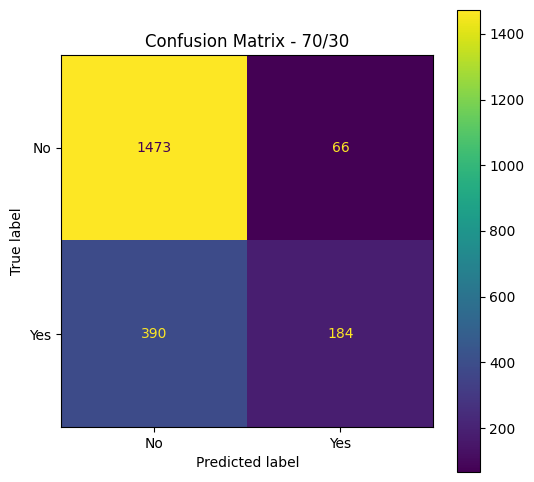

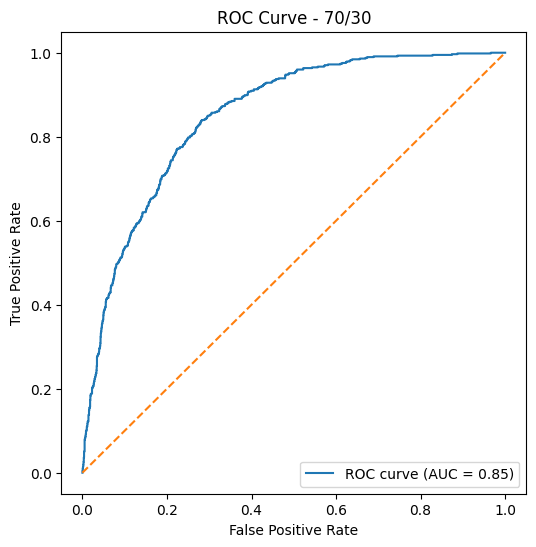

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_scores = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report - 70/30:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, ax=ax)
plt.title('Confusion Matrix - 70/30')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 70/30')
plt.legend(loc="lower right")
plt.show()

60/40

Classification Report - 60/40:
              precision    recall  f1-score   support

          No       0.89      0.82      0.86      2069
         Yes       0.60      0.72      0.65       749

    accuracy                           0.80      2818
   macro avg       0.74      0.77      0.76      2818
weighted avg       0.81      0.80      0.80      2818



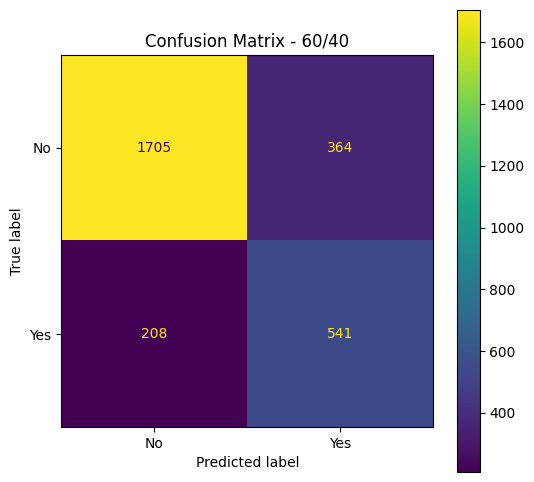

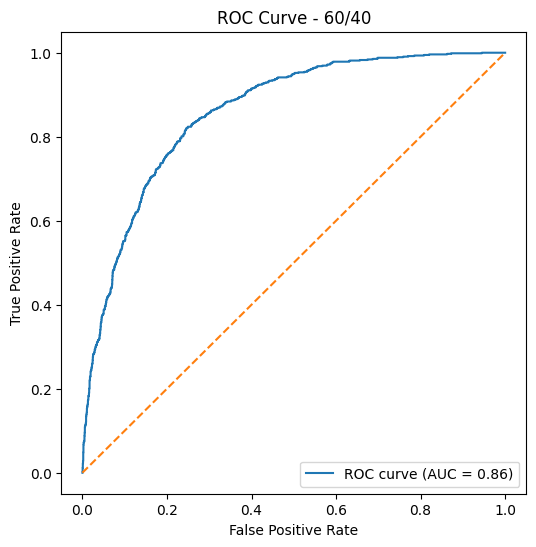

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_scores = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report - 60/40:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, ax=ax)
plt.title('Confusion Matrix - 60/40')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label='Yes')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 60/40')
plt.legend(loc="lower right")
plt.show()

##Task 8: 2D decision boundary visualization or inspect model feature coefficients

In [77]:
num_feature_names = list(num_features)

cat_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)

feature_names = num_feature_names + list(cat_feature_names)

coefficients = pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient',ascending=False)

print("Top Positive Coefficients:")
display(coef_df.head(10))

print("Top Negative Coefficients:")
display(coef_df.tail(10))

Top Positive Coefficients:


,Feature,Coefficient
16,InternetService_Fiber optic,1.230996
36,Contract_Month-to-month,1.018352
32,StreamingTV_Yes,0.717637
6,Partner_No,0.716862
11,PhoneService_Yes,0.676499
3,TotalCharges,0.669691
40,PaperlessBilling_Yes,0.662744
35,StreamingMovies_Yes,0.636377
8,Dependents_No,0.603890
26,DeviceProtection_Yes,0.579734


Top Negative Coefficients:


,Feature,Coefficient
22,OnlineBackup_No internet service,0.087810
17,InternetService_No,0.087810
34,StreamingMovies_No internet service,0.087810
31,StreamingTV_No internet service,0.087810
25,DeviceProtection_No internet service,0.087810
0,SeniorCitizen,-0.007980
15,InternetService_DSL,-0.253497
38,Contract_Two year,-0.371338
2,MonthlyCharges,-0.822067
1,tenure,-1.267779
